In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Set index col name to job_index
df.index.name = 'job_index'

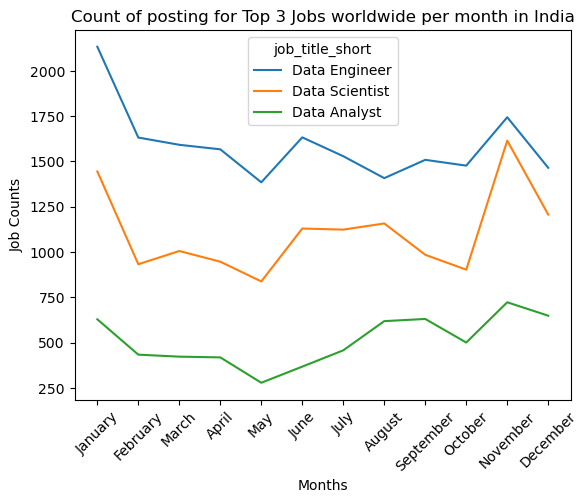

In [2]:
df_india_jobs = df[df['job_country'] == 'India'].copy()
# print(df_india_jobs.info())

# Adding new column of job_posted_month, but this time use strftime('%B') to extract month name, not index
df_india_jobs['job_posted_month'] = df_india_jobs['job_posted_date'].dt.strftime('%B')

# Finding top 3 Jobs in India
top3_Jobs_in_India = df_india_jobs['job_title_short'].value_counts().head(3) # By default Descending order
# print(top3_Jobs_in_India)
top3_Jobs_in_India = list(top3_Jobs_in_India.index)
# top3_Jobs_in_India

# df_india_jobs
rp = df_india_jobs.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')
# count also applicable, but best is not to use values, if we just need the count of items in each
# Intersection / Bucket

rp = rp[top3_Jobs_in_India] 
# We can't do rp[rp['job_title_short']==top3_Jobs_in_India] because pivot table makes the unique values of 
# job_title_short as the column headers.

# reset_index() is serving a very specific purpose: it moves the Month Names from being "labels" back into "data" so you can manipulate them.
rp.reset_index(inplace=True)


rp['job_posted_month_num'] = pd.to_datetime(rp['job_posted_month'], format='%B').dt.month
rp.sort_values(by = 'job_posted_month_num', inplace=True)


rp.drop(columns = 'job_posted_month_num', inplace=True)
rp.set_index('job_posted_month', inplace=True)

rp

rp.plot(kind='line')
plt.title("Count of posting for Top 3 Jobs worldwide per month in India")
plt.xlabel("Months")
plt.ylabel("Job Counts")
# Force show all month names on the X-axis
plt.xticks(ticks=range(len(rp.index)), labels=rp.index, rotation=45)
plt.show()

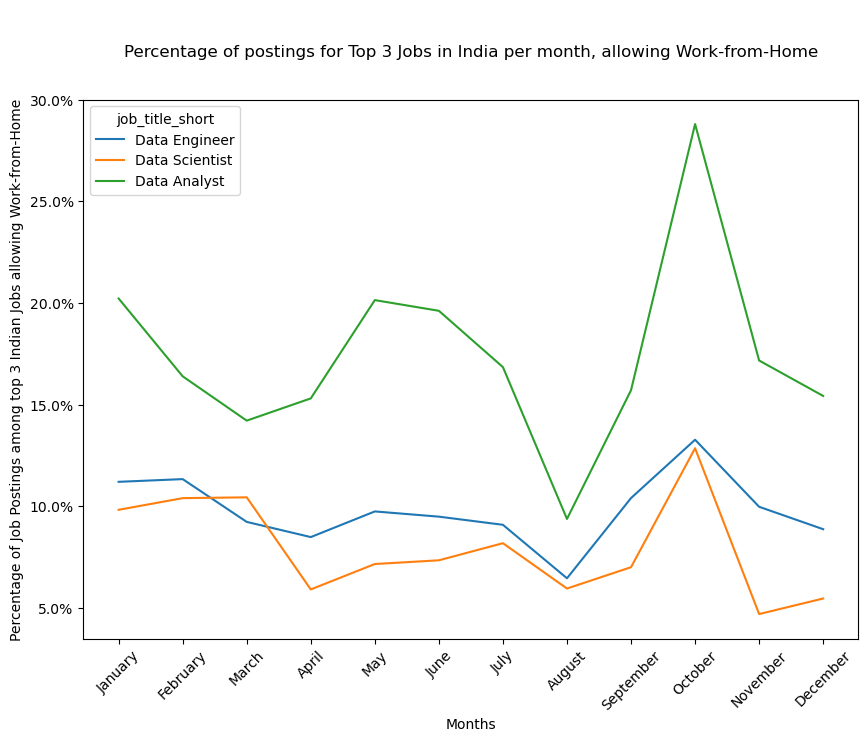

In [3]:
# Goal: Create a line chart showing the percentage (%) of jobs that offer "Work From Home" for the top 5 job titles in India over 12 months.
import matplotlib.ticker as mtick


# Creating the dataframe for only the Indian Jobs
df_india = df[df['job_country']=="India"].copy()

# Find out the top 5 jobs in India, store them in a List by putting the Series.index as List values
top_5_indian_jobs_series = df_india['job_title_short'].value_counts().head(3)
top_5_indian_jobs = list(top_5_indian_jobs_series.index)
# print(top_5_indian_jobs)

# Create the month names column
df_india['job_posted_month_name'] = df_india['job_posted_date'].dt.strftime('%B')
# Create the month number column
df_india['job_posted_month_num'] = pd.to_datetime(df_india['job_posted_month_name'], format='%B').dt.month
# df_india = df_india[df_india['job_work_from_home'] == True]

# df_india.info()

# After usage of pivot_table, job_title_short is no more a column, individual job titles are column labels
df_india_pivot = df_india.pivot_table(index=['job_posted_month_num', 'job_posted_month_name'], columns=['job_title_short'], values='job_work_from_home' , aggfunc='mean')
df_india_pivot = df_india_pivot[top_5_indian_jobs]
df_india_pivot = df_india_pivot * 100;
# As we have 2 columns, the leftmost is already the index column, no need to reset_index() and set_index()
# So we can directly sort by job_posted_month_num which is the index column
df_india_pivot.sort_index(inplace=True) # Leftmost column is Month num -> Index column
# print(df_india_pivot)
# Remove the job_posted_month_num from the original df for indian jobs, allowing Work from Home
df_india.drop(columns = 'job_posted_month_num', inplace=True)
# df_india.info() # Doesn't contain the job_posted_month_num column anymore
df_india_pivot.reset_index(inplace=True)
df_india_pivot.drop(columns=['job_posted_month_num'], inplace=True)
# Set index column back to job_posted_month name, as these are now already sorted by job_posted_month_num, and that column was dropped earlier
df_india_pivot.set_index('job_posted_month_name', inplace=True)
df_india_pivot

ax = df_india_pivot.plot(figsize=(10, 7))
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.title("\n\nPercentage of postings for Top 3 Jobs in India per month, allowing Work-from-Home\n\n")
plt.xlabel("Months")
plt.ylabel("Percentage of Job Postings among top 3 Indian Jobs allowing Work-from-Home")
# Force show all month names on the X-axis
plt.xticks(ticks=range(len(df_india_pivot.index)), labels=df_india_pivot.index, rotation=45)
plt.show()


